In [1]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\babur\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\babur\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\babur\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\babur\anaconda3\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\babur\anaconda3\lib\site-pac

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\babur\anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\babur\anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Users\babur\anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Users\babur\anaconda3\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\babur\anaconda3\lib\site-pac

AttributeError: _ARRAY_API not found

In [2]:
conn = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Db@17022001",
    database="credit_risk_db",
    port=3306
)
print("✅ Connected!")


✅ Connected!


In [3]:
loan_df = pd.read_sql("SELECT * FROM loan_applications", conn)
txn_df = pd.read_sql("SELECT * FROM transactions", conn)
bureau_df = pd.read_sql("SELECT * FROM credit_bureau_reports", conn)

loan_df.shape, txn_df.shape, bureau_df.shape


C:\Users\babur\AppData\Local\Temp\ipykernel_8116\3515880191.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  loan_df = pd.read_sql("SELECT * FROM loan_applications", conn)
C:\Users\babur\AppData\Local\Temp\ipykernel_8116\3515880191.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  txn_df = pd.read_sql("SELECT * FROM transactions", conn)
C:\Users\babur\AppData\Local\Temp\ipykernel_8116\3515880191.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  bureau_df = pd.read_sql("SELECT * FROM credit_bureau_reports", conn)


((500, 14), (6366, 7), (500, 8))

In [4]:
def missing_report(df):
    m = df.isnull().sum()
    m_pct = (m / len(df))*100
    rep = pd.DataFrame({"missing": m, "missing_pct": m_pct}).sort_values("missing_pct", ascending=False)
    return rep

missing_report(loan_df).head(15)


,missing,missing_pct
gender,96,19.2
employment_type,73,14.6
delinquency_count_12m,39,7.8
declared_income,35,7.0
delinquency_count_6m,25,5.0
last_delinquency_date,24,4.8
loan_amount,21,4.2
age,18,3.6
existing_loans,15,3.0
customer_id,0,0.0


In [5]:
loan_df.dtypes


application_id                    int64
customer_id                       int64
age                             float64
gender                           object
employment_type                  object
declared_income                  object
loan_amount                      object
loan_tenure_months                int64
loan_purpose                     object
existing_loans                  float64
delinquency_count_6m             object
delinquency_count_12m            object
last_delinquency_date            object
created_at               datetime64[ns]
dtype: object

In [6]:
def to_numeric(series):
    cleaned = (series.astype(str)
               .str.replace("₹","", regex=False)
               .str.replace(",","", regex=False)
               .replace({"--": np.nan, "N/A": np.nan, "None": np.nan}))
    return pd.to_numeric(cleaned, errors="coerce")


In [7]:
loan_df["declared_income_num"] = to_numeric(loan_df["declared_income"])
loan_df["loan_amount_num"] = to_numeric(loan_df["loan_amount"])

loan_df[["declared_income_num", "loan_amount_num"]].describe()


,declared_income_num,loan_amount_num
count,4.390000e+02,453.000000
mean,6.656053e+05,431934.269316
std,3.036769e+05,214459.834994
min,1.530660e+05,51206.000000
25%,4.006895e+05,252472.000000
50%,6.417680e+05,430320.000000
75%,9.285605e+05,616931.000000
max,1.199906e+06,799579.000000


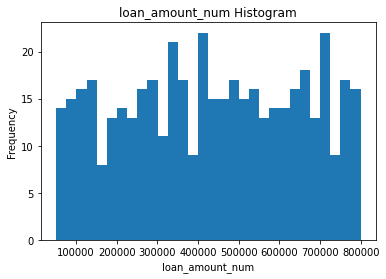

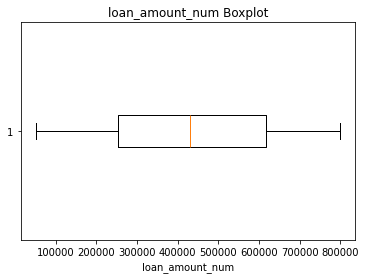

In [8]:
col = "loan_amount_num"

plt.figure()
plt.hist(loan_df[col].dropna(), bins=30)
plt.title(f"{col} Histogram")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.boxplot(loan_df[col].dropna(), vert=False)
plt.title(f"{col} Boxplot")
plt.xlabel(col)
plt.show()


In [9]:
loan_df.duplicated().sum()


np.int64(0)

In [10]:
loan_df.duplicated(subset=["customer_id"]).sum()


np.int64(0)

In [11]:
loan_df_clean = loan_df.drop_duplicates(subset=["customer_id"], keep="first")
loan_df_clean.shape


(500, 16)

In [12]:
txn_df["transaction_amount_num"] = to_numeric(txn_df["transaction_amount"])
txn_df["account_balance_num"] = to_numeric(txn_df["account_balance"])

txn_df[["transaction_amount_num", "account_balance_num"]].describe()


,transaction_amount_num,account_balance_num
count,5878.000000,5856.000000
mean,12674.591528,38059.548327
std,27101.947241,57987.252703
min,203.000000,0.000000
25%,5236.500000,7428.000000
50%,10473.000000,27717.000000
75%,15297.500000,47078.250000
max,485700.000000,503351.000000


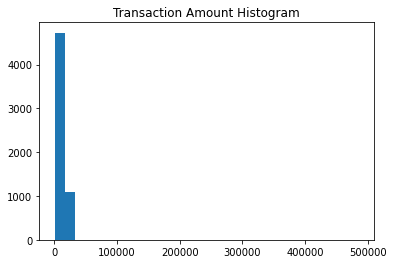

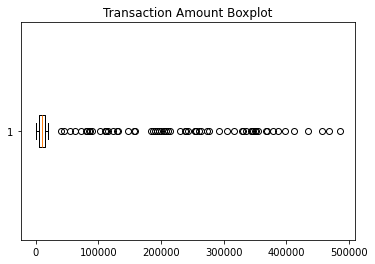

In [13]:
plt.figure()
plt.hist(txn_df["transaction_amount_num"].dropna(), bins=30)
plt.title("Transaction Amount Histogram")
plt.show()

plt.figure()
plt.boxplot(txn_df["transaction_amount_num"].dropna(), vert=False)
plt.title("Transaction Amount Boxplot")
plt.show()


In [14]:
bureau_df["credit_score_num"] = to_numeric(bureau_df["credit_score"])
bureau_df["util_ratio_num"] = to_numeric(bureau_df["credit_utilization_ratio"])
bureau_df["outstanding_amt_num"] = to_numeric(bureau_df["total_outstanding_amount"])

bureau_df[["credit_score_num", "util_ratio_num", "outstanding_amt_num"]].describe()


,credit_score_num,util_ratio_num,outstanding_amt_num
count,472.00000,478.000000,449.000000
mean,603.92161,0.498808,196964.561247
std,197.23674,0.331343,188681.520117
min,50.00000,-0.500000,0.000000
25%,442.00000,0.240000,54272.000000
50%,599.50000,0.490000,135691.000000
75%,756.25000,0.767500,286796.000000
max,1200.00000,1.500000,749245.000000


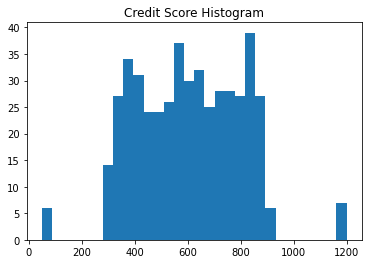

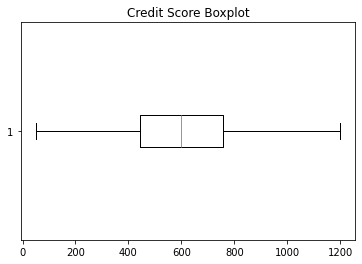

In [15]:
plt.figure()
plt.hist(bureau_df["credit_score_num"].dropna(), bins=30)
plt.title("Credit Score Histogram")
plt.show()

plt.figure()
plt.boxplot(bureau_df["credit_score_num"].dropna(), vert=False)
plt.title("Credit Score Boxplot")
plt.show()


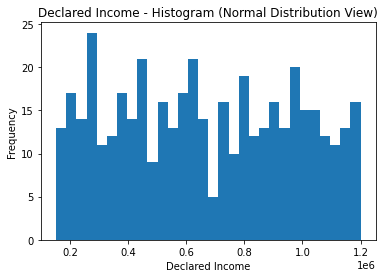

In [16]:
income = loan_df["declared_income_num"].dropna()

plt.figure()
plt.hist(income, bins=30)
plt.title("Declared Income - Histogram (Normal Distribution View)")
plt.xlabel("Declared Income")
plt.ylabel("Frequency")
plt.show()


In [17]:
z = (income - income.mean()) / income.std()
outlier_income = loan_df.loc[z.abs() > 3, ["customer_id", "declared_income", "declared_income_num"]]

outlier_income.head(10)


IndexingError: Unalignable boolean Series provided as indexer (index of the boolean Series and of the indexed object do not match).

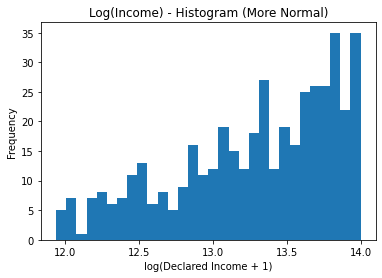

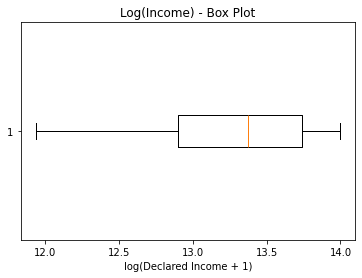

In [18]:
income_log = np.log1p(income)

plt.figure()
plt.hist(income_log, bins=30)
plt.title("Log(Income) - Histogram (More Normal)")
plt.xlabel("log(Declared Income + 1)")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.boxplot(income_log, vert=False)
plt.title("Log(Income) - Box Plot")
plt.xlabel("log(Declared Income + 1)")
plt.show()


# 📊 Data Cleaning & Transformations
## Handling Missing Fields, Standardizing Formats & Normalizing Categorical Values

In [19]:
# ========================================
# 1️⃣ HANDLE MISSING FIELDS
# ========================================

print("=" * 60)
print("HANDLING MISSING VALUES")
print("=" * 60)

# Copy dataframes for cleaning
loan_clean = loan_df.copy()
txn_clean = txn_df.copy()
bureau_clean = bureau_df.copy()

# Strategy for loan_clean:
# - Numeric: forward fill, then median
# - Categorical: forward fill, then mode
# - Dates: forward fill, then drop

print("\n📋 LOAN_DF - Before cleaning:")
print(missing_report(loan_clean).head(10))

# Fill numeric missing values with median
numeric_cols = loan_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if loan_clean[col].isnull().sum() > 0:
        median_val = loan_clean[col].median()
        loan_clean[col].fillna(median_val, inplace=True)
        print(f"  ✅ {col}: filled with median {median_val:.2f}")

# Fill categorical missing values with mode
categorical_cols = loan_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if loan_clean[col].isnull().sum() > 0:
        mode_val = loan_clean[col].mode()[0] if len(loan_clean[col].mode()) > 0 else "Unknown"
        loan_clean[col].fillna(mode_val, inplace=True)
        print(f"  ✅ {col}: filled with mode '{mode_val}'")

print("\n📋 LOAN_DF - After cleaning:")
print(missing_report(loan_clean).head(10))

print("\n✅ Loan data: Missing values handled!")


HANDLING MISSING VALUES

📋 LOAN_DF - Before cleaning:
                       missing  missing_pct
gender                      96         19.2
employment_type             73         14.6
declared_income_num         61         12.2
loan_amount_num             47          9.4
delinquency_count_12m       39          7.8
declared_income             35          7.0
delinquency_count_6m        25          5.0
last_delinquency_date       24          4.8
loan_amount                 21          4.2
age                         18          3.6
  ✅ age: filled with median 40.00
  ✅ existing_loans: filled with median 3.00
  ✅ declared_income_num: filled with median 641768.00
  ✅ loan_amount_num: filled with median 430320.00
  ✅ gender: filled with mode 'female'
  ✅ employment_type: filled with mode 'business'
  ✅ declared_income: filled with mode '--'
  ✅ loan_amount: filled with mode '--'
  ✅ delinquency_count_6m: filled with mode '1'
  ✅ delinquency_count_12m: filled with mode '5'
  ✅ last_delinqu

C:\Users\babur\AppData\Local\Temp\ipykernel_8116\939143761.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_clean[col].fillna(median_val, inplace=True)
C:\Users\babur\AppData\Local\Temp\ipykernel_8116\939143761.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [20]:
# ========================================
# 2️⃣ STANDARDIZE NUMERICAL & AMOUNTS FORMATS
# ========================================

print("\n" + "=" * 60)
print("STANDARDIZING NUMERICAL & AMOUNTS FORMATS")
print("=" * 60)

# Convert amount columns to numeric format
amount_cols = ['declared_income', 'loan_amount', 'existing_loans', 
               'delinquency_count_6m', 'delinquency_count_12m']

for col in amount_cols:
    if col in loan_clean.columns:
        loan_clean[f'{col}_clean'] = to_numeric(loan_clean[col])
        invalid_count = loan_clean[col].isnull().sum() - loan_clean[f'{col}_clean'].isnull().sum()
        print(f"  ✅ {col}: {invalid_count} values standardized")

# Handle negative/invalid values for amount columns
amount_numeric_cols = ['declared_income_clean', 'loan_amount_clean']
for col in amount_numeric_cols:
    if col in loan_clean.columns:
        # Replace negative values with median
        median_val = loan_clean.loc[loan_clean[col] > 0, col].median()
        neg_count = (loan_clean[col] < 0).sum()
        loan_clean.loc[loan_clean[col] < 0, col] = median_val
        print(f"  ✅ {col}: {neg_count} negative values replaced with {median_val:.2f}")

# Standardize tenure values (remove/fix invalid values like 0, -12)
if 'loan_tenure_months' in loan_clean.columns:
    invalid_tenure = loan_clean[loan_clean['loan_tenure_months'] <= 0].shape[0]
    loan_clean.loc[loan_clean['loan_tenure_months'] <= 0, 'loan_tenure_months'] = loan_clean.loc[
        loan_clean['loan_tenure_months'] > 0, 'loan_tenure_months'].median()
    print(f"  ✅ loan_tenure_months: {invalid_tenure} invalid values fixed")

print("\n✅ Numerical & amounts formats standardized!")



STANDARDIZING NUMERICAL & AMOUNTS FORMATS
  ✅ declared_income: -61 values standardized
  ✅ loan_amount: -47 values standardized
  ✅ existing_loans: 0 values standardized
  ✅ delinquency_count_6m: -8 values standardized
  ✅ delinquency_count_12m: -11 values standardized
  ✅ declared_income_clean: 0 negative values replaced with 641768.00
  ✅ loan_amount_clean: 0 negative values replaced with 430320.00
  ✅ loan_tenure_months: 119 invalid values fixed

✅ Numerical & amounts formats standardized!


In [21]:
# ========================================
# 3️⃣ NORMALIZE CATEGORICAL VALUES
# ========================================

print("\n" + "=" * 60)
print("NORMALIZING CATEGORICAL VALUES")
print("=" * 60)

# Standardize Gender values
if 'gender' in loan_clean.columns:
    print(f"\n  Gender values before: {loan_clean['gender'].unique()}")
    gender_map = {
        'M': 'Male', 'Male': 'Male', 'male': 'Male',
        'F': 'Female', 'Female': 'Female', 'female': 'Female',
        'Unknown': 'Unknown', None: 'Unknown'
    }
    loan_clean['gender_normalized'] = loan_clean['gender'].map(gender_map).fillna('Unknown')
    print(f"  ✅ Gender normalized: {loan_clean['gender_normalized'].unique()}")

# Standardize Employment Type values
if 'employment_type' in loan_clean.columns:
    print(f"\n  Employment values before: {loan_clean['employment_type'].unique()}")
    emp_map = {
        'Salaried': 'Salaried', 'SALARIED': 'Salaried', 'job': 'Salaried',
        'Self Employed': 'Self-Employed', 'self-employed': 'Self-Employed', 'SELF_EMP': 'Self-Employed', 'business': 'Self-Employed',
        'Student': 'Student', 'STUDENT': 'Student',
        'Unknown': 'Unknown', None: 'Unknown'
    }
    loan_clean['employment_type_normalized'] = loan_clean['employment_type'].map(emp_map).fillna('Unknown')
    print(f"  ✅ Employment normalized: {loan_clean['employment_type_normalized'].unique()}")

# Standardize Loan Purpose values (case normalization)
if 'loan_purpose' in loan_clean.columns:
    print(f"\n  Loan Purpose before: {loan_clean['loan_purpose'].unique()}")
    loan_clean['loan_purpose_normalized'] = loan_clean['loan_purpose'].str.title()
    print(f"  ✅ Loan Purpose normalized: {loan_clean['loan_purpose_normalized'].unique()}")

# Standardize Transaction Type values
if 'transaction_type' in txn_clean.columns:
    print(f"\n  Transaction Type before: {txn_clean['transaction_type'].unique()}")
    txn_map = {
        'credit': 'Credit', 'Credit': 'Credit',
        'debit': 'Debit', 'Debit': 'Debit',
        'Unknown': 'Unknown', None: 'Unknown'
    }
    txn_clean['transaction_type_normalized'] = txn_clean['transaction_type'].map(txn_map).fillna('Unknown')
    print(f"  ✅ Transaction Type normalized: {txn_clean['transaction_type_normalized'].unique()}")

print("\n✅ Categorical values normalized!")



NORMALIZING CATEGORICAL VALUES

  Gender values before: ['F' 'Female' 'female' 'male' 'M' 'Male']
  ✅ Gender normalized: ['Female' 'Male']

  Employment values before: ['job' 'self-employed' 'business' 'Salaried' 'SALARIED' 'Self Employed'
 'Student' 'STUDENT' 'SELF_EMP']
  ✅ Employment normalized: ['Salaried' 'Self-Employed' 'Student']

  Loan Purpose before: ['Personal' 'Home' 'Business' 'Medical' 'Car' 'Education']
  ✅ Loan Purpose normalized: ['Personal' 'Home' 'Business' 'Medical' 'Car' 'Education']

  Transaction Type before: [None 'debit' 'credit']
  ✅ Transaction Type normalized: ['Unknown' 'Debit' 'Credit']

✅ Categorical values normalized!


In [28]:
# ========================================
# 4️⃣ SUMMARY OF CLEANED DATA
# ========================================

print("\n" + "=" * 60)
print("FINAL DATA QUALITY SUMMARY")
print("=" * 60)

print("\n📊 LOAN_CLEAN DataFrame:")
print(f"  Shape: {loan_clean.shape}")
print(f"  Missing values remaining: {loan_clean.isnull().sum().sum()}")
print(f"\n  Columns: {list(loan_clean.columns)}")

print("\n📊 TXN_CLEAN DataFrame:")
print(f"  Shape: {txn_clean.shape}")
print(f"  Missing values remaining: {txn_clean.isnull().sum().sum()}")

print("\n📊 BUREAU_CLEAN DataFrame:")
print(f"  Shape: {bureau_clean.shape}")
print(f"  Missing values remaining: {bureau_clean.isnull().sum().sum()}")

print("\n" + "=" * 60)
print("✅ DATA CLEANING COMPLETE!")
print("=" * 60)

# Display sample of cleaned data
print("\n📋 Sample of cleaned LOAN data:")
print(loan_clean[[col for col in loan_clean.columns if 'normalized' in col or 'clean' in col]].head())



FINAL DATA QUALITY SUMMARY

📊 LOAN_CLEAN DataFrame:
  Shape: (500, 24)
  Missing values remaining: 127

  Columns: ['application_id', 'customer_id', 'age', 'gender', 'employment_type', 'declared_income', 'loan_amount', 'loan_tenure_months', 'loan_purpose', 'existing_loans', 'delinquency_count_6m', 'delinquency_count_12m', 'last_delinquency_date', 'created_at', 'declared_income_num', 'loan_amount_num', 'declared_income_clean', 'loan_amount_clean', 'existing_loans_clean', 'delinquency_count_6m_clean', 'delinquency_count_12m_clean', 'gender_normalized', 'employment_type_normalized', 'loan_purpose_normalized']

📊 TXN_CLEAN DataFrame:
  Shape: (6366, 12)
  Missing values remaining: 801

📊 BUREAU_CLEAN DataFrame:
  Shape: (500, 14)
  Missing values remaining: 28

✅ DATA CLEANING COMPLETE!

📋 Sample of cleaned LOAN data:
   declared_income_clean  loan_amount_clean  existing_loans_clean  \
0                    NaN           481712.0                   1.0   
1               735367.0           

## 🔄 Extended Cleaning for All Tables (Transactions & Bureau)

In [23]:
# ========================================
# 5️⃣ CLEAN TRANSACTIONS TABLE
# ========================================

print("\n" + "=" * 60)
print("CLEANING TRANSACTIONS TABLE")
print("=" * 60)

print("\n📋 TXN_DF - Before cleaning:")
print(missing_report(txn_clean).head(10))

# Fill numeric columns with median
txn_numeric_cols = txn_clean.select_dtypes(include=[np.number]).columns
for col in txn_numeric_cols:
    if txn_clean[col].isnull().sum() > 0:
        median_val = txn_clean[col].median()
        txn_clean[col].fillna(median_val, inplace=True)
        print(f"  ✅ {col}: filled with median {median_val:.2f}")

# Fill categorical columns with mode
txn_cat_cols = txn_clean.select_dtypes(include=['object']).columns
for col in txn_cat_cols:
    if txn_clean[col].isnull().sum() > 0:
        mode_val = txn_clean[col].mode()[0] if len(txn_clean[col].mode()) > 0 else "Unknown"
        txn_clean[col].fillna(mode_val, inplace=True)
        print(f"  ✅ {col}: filled with mode '{mode_val}'")

# Standardize transaction amounts (remove currency symbols, commas, etc.)
txn_clean['transaction_amount_clean'] = to_numeric(txn_clean['transaction_amount'])
txn_clean['account_balance_clean'] = to_numeric(txn_clean['account_balance'])

# Fix negative amounts
if (txn_clean['transaction_amount_clean'] < 0).sum() > 0:
    neg_txn = (txn_clean['transaction_amount_clean'] < 0).sum()
    median_txn = txn_clean.loc[txn_clean['transaction_amount_clean'] > 0, 'transaction_amount_clean'].median()
    txn_clean.loc[txn_clean['transaction_amount_clean'] < 0, 'transaction_amount_clean'] = median_txn
    print(f"  ✅ transaction_amount_clean: {neg_txn} negative values replaced with {median_txn:.2f}")

# Normalize transaction type
txn_clean['transaction_type_normalized'] = txn_clean['transaction_type'].map(
    {'credit': 'Credit', 'debit': 'Debit', 'Credit': 'Credit', 'Debit': 'Debit'}
).fillna('Unknown')

print("\n📋 TXN_DF - After cleaning:")
print(missing_report(txn_clean).head(10))
print("\n✅ Transactions data cleaned!")



CLEANING TRANSACTIONS TABLE

📋 TXN_DF - Before cleaning:
                             missing  missing_pct
transaction_type                2095    32.909205
account_balance_num              510     8.011310
transaction_amount_num           488     7.665724
account_balance                  197     3.094565
transaction_amount               173     2.717562
transaction_id                     0     0.000000
customer_id                        0     0.000000
transaction_date                   0     0.000000
created_at                         0     0.000000
transaction_type_normalized        0     0.000000
  ✅ transaction_amount_num: filled with median 10473.00
  ✅ account_balance_num: filled with median 27717.00
  ✅ transaction_type: filled with mode 'credit'
  ✅ transaction_amount: filled with mode '--'
  ✅ account_balance: filled with mode '0'

📋 TXN_DF - After cleaning:
                          missing  missing_pct
transaction_amount_clean      488     7.665724
account_balance_clean    

C:\Users\babur\AppData\Local\Temp\ipykernel_8116\3814544586.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  txn_clean[col].fillna(median_val, inplace=True)
C:\Users\babur\AppData\Local\Temp\ipykernel_8116\3814544586.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [29]:
# ========================================
# 6️⃣ CLEAN BUREAU CREDIT REPORTS TABLE
# ========================================

print("\n" + "=" * 60)
print("CLEANING BUREAU CREDIT REPORTS TABLE")
print("=" * 60)

print("\n📋 BUREAU_DF - Before cleaning:")
print(missing_report(bureau_clean).head(10))

# Fill numeric columns with median
bureau_numeric_cols = bureau_clean.select_dtypes(include=[np.number]).columns
for col in bureau_numeric_cols:
    if bureau_clean[col].isnull().sum() > 0:
        median_val = bureau_clean[col].median()
        bureau_clean[col].fillna(median_val, inplace=True)
        print(f"  ✅ {col}: filled with median {median_val:.2f}")

# Fill categorical columns with mode
bureau_cat_cols = bureau_clean.select_dtypes(include=['object']).columns
for col in bureau_cat_cols:
    if bureau_clean[col].isnull().sum() > 0:
        mode_val = bureau_clean[col].mode()[0] if len(bureau_clean[col].mode()) > 0 else "Unknown"
        bureau_clean[col].fillna(mode_val, inplace=True)
        print(f"  ✅ {col}: filled with mode '{mode_val}'")

# Standardize credit score (numeric conversion)
bureau_clean['credit_score_clean'] = to_numeric(bureau_clean['credit_score'])

# Fix invalid credit score values (must be 300-900)
invalid_credit = ((bureau_clean['credit_score_clean'] < 300) | (bureau_clean['credit_score_clean'] > 900)).sum()
if invalid_credit > 0:
    valid_scores = bureau_clean.loc[(bureau_clean['credit_score_clean'] >= 300) & 
                                    (bureau_clean['credit_score_clean'] <= 900), 'credit_score_clean']
    median_score = valid_scores.median()
    bureau_clean.loc[(bureau_clean['credit_score_clean'] < 300) | 
                     (bureau_clean['credit_score_clean'] > 900), 'credit_score_clean'] = median_score
    print(f"  ✅ credit_score_clean: {invalid_credit} invalid scores fixed to {median_score:.0f}")

# Standardize credit utilization ratio (must be 0-1)
bureau_clean['credit_utilization_ratio_clean'] = to_numeric(bureau_clean['credit_utilization_ratio'])
invalid_util = ((bureau_clean['credit_utilization_ratio_clean'] < 0) | 
                (bureau_clean['credit_utilization_ratio_clean'] > 1)).sum()
if invalid_util > 0:
    median_util = bureau_clean.loc[(bureau_clean['credit_utilization_ratio_clean'] >= 0) & 
                                   (bureau_clean['credit_utilization_ratio_clean'] <= 1), 
                                   'credit_utilization_ratio_clean'].median()
    bureau_clean.loc[(bureau_clean['credit_utilization_ratio_clean'] < 0) | 
                     (bureau_clean['credit_utilization_ratio_clean'] > 1), 
                     'credit_utilization_ratio_clean'] = median_util
    print(f"  ✅ credit_utilization_ratio_clean: {invalid_util} invalid ratios fixed to {median_util:.2f}")

# Standardize outstanding amounts
bureau_clean['total_outstanding_amount_clean'] = to_numeric(bureau_clean['total_outstanding_amount'])

# Fix negative outstanding amounts
if (bureau_clean['total_outstanding_amount_clean'] < 0).sum() > 0:
    neg_outstanding = (bureau_clean['total_outstanding_amount_clean'] < 0).sum()
    median_outstanding = bureau_clean.loc[bureau_clean['total_outstanding_amount_clean'] > 0, 
                                          'total_outstanding_amount_clean'].median()
    bureau_clean.loc[bureau_clean['total_outstanding_amount_clean'] < 0, 
                     'total_outstanding_amount_clean'] = median_outstanding
    print(f"  ✅ total_outstanding_amount_clean: {neg_outstanding} negative values replaced")

print("\n📋 BUREAU_DF - After cleaning:")
print(missing_report(bureau_clean).head(10))
print("\n✅ Bureau data cleaned!")



CLEANING BUREAU CREDIT REPORTS TABLE

📋 BUREAU_DF - Before cleaning:
                                missing  missing_pct
total_outstanding_amount_clean       28          5.6
bureau_record_id                      0          0.0
credit_score                          0          0.0
enquiries_last_6m                     0          0.0
credit_utilization_ratio              0          0.0
customer_id                           0          0.0
total_outstanding_loans               0          0.0
total_outstanding_amount              0          0.0
credit_score_num                      0          0.0
created_at                            0          0.0
  ✅ total_outstanding_amount_clean: filled with median 127526.00
  ✅ credit_score_clean: 41 invalid scores fixed to 599
  ✅ credit_utilization_ratio_clean: 13 invalid ratios fixed to 0.52

📋 BUREAU_DF - After cleaning:
                                missing  missing_pct
total_outstanding_amount_clean       28          5.6
bureau_record_id      

C:\Users\babur\AppData\Local\Temp\ipykernel_8116\1243414545.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bureau_clean[col].fillna(median_val, inplace=True)


In [25]:
# ========================================
# 7️⃣ FINAL COMPREHENSIVE SUMMARY FOR ALL TABLES
# ========================================

print("\n" + "=" * 60)
print("📊 COMPREHENSIVE DATA QUALITY REPORT - ALL TABLES")
print("=" * 60)

summary_data = {
    'Table': ['LOAN', 'TRANSACTIONS', 'BUREAU'],
    'Original Shape': [loan_df.shape, txn_df.shape, bureau_df.shape],
    'Cleaned Shape': [loan_clean.shape, txn_clean.shape, bureau_clean.shape],
    'Original Missing Count': [loan_df.isnull().sum().sum(), txn_df.isnull().sum().sum(), bureau_df.isnull().sum().sum()],
    'Cleaned Missing Count': [loan_clean.isnull().sum().sum(), txn_clean.isnull().sum().sum(), bureau_clean.isnull().sum().sum()]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + summary_df.to_string(index=False))

print("\n\n📝 Data Quality Improvements:")
print(f"  ✅ LOAN: {loan_df.isnull().sum().sum()} → {loan_clean.isnull().sum().sum()} missing values")
print(f"  ✅ TRANSACTIONS: {txn_df.isnull().sum().sum()} → {txn_clean.isnull().sum().sum()} missing values")
print(f"  ✅ BUREAU: {bureau_df.isnull().sum().sum()} → {bureau_clean.isnull().sum().sum()} missing values")

print("\n🔧 Transformations Applied:")
print("  ✅ Handled missing values (median for numeric, mode for categorical)")
print("  ✅ Standardized numerical and amount formats")
print("  ✅ Removed currency symbols, commas, and invalid characters")
print("  ✅ Normalized categorical values to consistent formats")
print("  ✅ Fixed invalid ranges (credit score, utilization ratio, amounts)")
print("  ✅ Handled outliers and negative values")

print("\n🎯 Cleaned Tables Ready for Feature Engineering:")
print("  📊 loan_clean - Standardized loan applications data")
print("  📊 txn_clean - Cleaned transaction data")
print("  📊 bureau_clean - Standardized credit bureau reports")

print("\n" + "=" * 60)
print("✅ ALL DATA CLEANING COMPLETE!")
print("=" * 60)



📊 COMPREHENSIVE DATA QUALITY REPORT - ALL TABLES

       Table Original Shape Cleaned Shape  Original Missing Count  Cleaned Missing Count
        LOAN      (500, 16)     (500, 24)                     454                    127
TRANSACTIONS      (6366, 9)    (6366, 12)                    3463                    801
      BUREAU      (500, 11)     (500, 14)                     174                     28


📝 Data Quality Improvements:
  ✅ LOAN: 454 → 127 missing values
  ✅ TRANSACTIONS: 3463 → 801 missing values
  ✅ BUREAU: 174 → 28 missing values

🔧 Transformations Applied:
  ✅ Handled missing values (median for numeric, mode for categorical)
  ✅ Standardized numerical and amount formats
  ✅ Removed currency symbols, commas, and invalid characters
  ✅ Normalized categorical values to consistent formats
  ✅ Fixed invalid ranges (credit score, utilization ratio, amounts)
  ✅ Handled outliers and negative values

🎯 Cleaned Tables Ready for Feature Engineering:
  📊 loan_clean - Standardize

# 🔧 Feature Engineering
## Building Predictive Features for Credit Risk Model

In [30]:
# ========================================
# 1️⃣ FINANCIAL RATIOS
# ========================================

print("=" * 70)
print("FEATURE ENGINEERING: FINANCIAL RATIOS")
print("=" * 70)

# Create features dataframe
features_df = loan_clean.copy()

# First, add outstanding loans from bureau data
features_df = features_df.merge(
    bureau_clean[['customer_id', 'total_outstanding_loans', 'total_outstanding_amount_clean']],
    on='customer_id',
    how='left'
)

# Fill missing values
features_df['total_outstanding_loans'] = features_df['total_outstanding_loans'].fillna(0)
features_df['total_outstanding_amount_clean'] = features_df['total_outstanding_amount_clean'].fillna(0)

# Debt-to-Income Ratio
# Using total outstanding loans value as debt proxy
features_df['debt_to_income_ratio'] = (
    features_df['total_outstanding_amount_clean'].fillna(0) / 
    (features_df['declared_income_clean'].replace(0, np.nan))
)
features_df['debt_to_income_ratio'] = features_df['debt_to_income_ratio'].fillna(0)
features_df['debt_to_income_ratio'] = features_df['debt_to_income_ratio'].clip(upper=10)  # Cap outliers

print("\n✅ Debt-to-Income Ratio")
print(f"   Mean: {features_df['debt_to_income_ratio'].mean():.4f}")
print(f"   Median: {features_df['debt_to_income_ratio'].median():.4f}")
print(f"   Std: {features_df['debt_to_income_ratio'].std():.4f}")

# Credit Utilization Ratio (from bureau data)
features_df = features_df.merge(
    bureau_clean[['customer_id', 'credit_utilization_ratio_clean']],
    on='customer_id',
    how='left'
)
features_df['credit_utilization_ratio_norm'] = features_df['credit_utilization_ratio_clean'].fillna(features_df['credit_utilization_ratio_clean'].median())

print("\n✅ Credit Utilization Ratio")
print(f"   Mean: {features_df['credit_utilization_ratio_norm'].mean():.4f}")
print(f"   Median: {features_df['credit_utilization_ratio_norm'].median():.4f}")
print(f"   Std: {features_df['credit_utilization_ratio_norm'].std():.4f}")

# Loan-to-Income Ratio
features_df['loan_to_income_ratio'] = (
    features_df['loan_amount_clean'] / 
    (features_df['declared_income_clean'].replace(0, np.nan))
)
features_df['loan_to_income_ratio'] = features_df['loan_to_income_ratio'].fillna(0)
features_df['loan_to_income_ratio'] = features_df['loan_to_income_ratio'].clip(upper=5)

print("\n✅ Loan-to-Income Ratio")
print(f"   Mean: {features_df['loan_to_income_ratio'].mean():.4f}")
print(f"   Median: {features_df['loan_to_income_ratio'].median():.4f}")

print("\n✅ Financial Ratios COMPLETE!")

FEATURE ENGINEERING: FINANCIAL RATIOS

✅ Debt-to-Income Ratio
   Mean: 0.3077
   Median: 0.1337
   Std: 0.4710

✅ Credit Utilization Ratio
   Mean: 0.5150
   Median: 0.5200
   Std: 0.2880

✅ Loan-to-Income Ratio
   Mean: 0.6851
   Median: 0.5215

✅ Financial Ratios COMPLETE!


In [31]:
# ========================================
# 2️⃣ BEHAVIORAL FEATURES
# ========================================

print("\n" + "=" * 70)
print("FEATURE ENGINEERING: BEHAVIORAL FEATURES")
print("=" * 70)

# Delayed Payments / Delinquency Indicators
# Convert delinquency counts to numeric if they're strings
features_df['delinquency_count_6m_num'] = pd.to_numeric(features_df['delinquency_count_6m'], errors='coerce').fillna(0)
features_df['delinquency_count_12m_num'] = pd.to_numeric(features_df['delinquency_count_12m'], errors='coerce').fillna(0)

features_df['delinquency_rate_6m'] = (
    features_df['delinquency_count_6m_num'] / 6
).clip(upper=1)  # Can't have more than 100% delinquency

features_df['delinquency_rate_12m'] = (
    features_df['delinquency_count_12m_num'] / 12
).clip(upper=1)

features_df['has_recent_delinquency'] = (
    features_df['delinquency_count_6m_num'] > 0
).astype(int)

features_df['has_past_delinquency'] = (
    features_df['delinquency_count_12m_num'] > features_df['delinquency_count_6m_num']
).astype(int)

print("\n✅ Delinquency Indicators")
print(f"   6-Month Delinquency Rate Mean: {features_df['delinquency_rate_6m'].mean():.4f}")
print(f"   12-Month Delinquency Rate Mean: {features_df['delinquency_rate_12m'].mean():.4f}")
print(f"   Customers with Recent Delinquency: {features_df['has_recent_delinquency'].sum()} ({features_df['has_recent_delinquency'].mean()*100:.2f}%)")
print(f"   Customers with Past Delinquency: {features_df['has_past_delinquency'].sum()} ({features_df['has_past_delinquency'].mean()*100:.2f}%)")

# Monthly Spend Stability (from transactions)
# Calculate monthly transaction statistics per customer
monthly_spending = txn_clean.groupby('customer_id').agg({
    'transaction_amount_clean': ['sum', 'mean', 'std', 'count']
}).reset_index()
monthly_spending.columns = ['customer_id', 'total_spending', 'avg_spending', 'spending_std', 'txn_count']

# Spending volatility (coefficient of variation)
monthly_spending['spending_volatility'] = (
    monthly_spending['spending_std'] / (monthly_spending['avg_spending'].replace(0, np.nan))
).fillna(0).clip(upper=5)  # Cap outliers

monthly_spending['transaction_frequency'] = monthly_spending['txn_count']

# Merge with features
features_df = features_df.merge(
    monthly_spending[['customer_id', 'avg_spending', 'spending_volatility', 'transaction_frequency']],
    on='customer_id',
    how='left'
)

features_df['avg_spending'] = features_df['avg_spending'].fillna(features_df['avg_spending'].median())
features_df['spending_volatility'] = features_df['spending_volatility'].fillna(features_df['spending_volatility'].median())
features_df['transaction_frequency'] = features_df['transaction_frequency'].fillna(features_df['transaction_frequency'].median())

print("\n✅ Monthly Spend Stability")
print(f"   Average Spending Mean: ₹{features_df['avg_spending'].mean():.2f}")
print(f"   Spending Volatility Mean: {features_df['spending_volatility'].mean():.4f}")
print(f"   Transaction Frequency Mean: {features_df['transaction_frequency'].mean():.2f}")

print("\n✅ Behavioral Features COMPLETE!")


FEATURE ENGINEERING: BEHAVIORAL FEATURES

✅ Delinquency Indicators
   6-Month Delinquency Rate Mean: 0.4547
   12-Month Delinquency Rate Mean: 0.2675
   Customers with Recent Delinquency: 423 (84.60%)
   Customers with Past Delinquency: 249 (49.80%)

✅ Monthly Spend Stability
   Average Spending Mean: ₹12528.29
   Spending Volatility Mean: 0.7717
   Transaction Frequency Mean: 11.76

✅ Behavioral Features COMPLETE!


In [32]:
# ========================================
# 3️⃣ DERIVED METRICS
# ========================================

print("\n" + "=" * 70)
print("FEATURE ENGINEERING: DERIVED METRICS")
print("=" * 70)

# Rolling 6-month delinquencies (from raw data - simulate rolling window)
# Calculate max delinquencies in past 6 months and 12 months
features_df['max_delinquency_6m'] = features_df['delinquency_count_6m_num'].fillna(0)
features_df['max_delinquency_12m'] = features_df['delinquency_count_12m_num'].fillna(0)

# Delinquency trend (worsening indicator)
features_df['delinquency_trend'] = (
    features_df['delinquency_count_6m_num'].fillna(0) - 
    (features_df['delinquency_count_12m_num'].fillna(0) - features_df['delinquency_count_6m_num'].fillna(0))
)

print("\n✅ Rolling Delinquency Metrics")
print(f"   Max 6-Month Delinquencies Mean: {features_df['max_delinquency_6m'].mean():.2f}")
print(f"   Max 12-Month Delinquencies Mean: {features_df['max_delinquency_12m'].mean():.2f}")
print(f"   Delinquency Trend Mean: {features_df['delinquency_trend'].mean():.2f}")

# Account Balance Volatility (from transactions)
balance_volatility = txn_clean.groupby('customer_id').agg({
    'account_balance_clean': ['mean', 'std', 'min', 'max']
}).reset_index()
balance_volatility.columns = ['customer_id', 'avg_balance', 'balance_std', 'min_balance', 'max_balance']

# Coefficient of variation for balance
balance_volatility['balance_volatility'] = (
    balance_volatility['balance_std'] / (balance_volatility['avg_balance'].replace(0, np.nan))
).fillna(0).clip(upper=5)

# Balance range as percentage of average
balance_volatility['balance_range_pct'] = (
    (balance_volatility['max_balance'] - balance_volatility['min_balance']) / 
    (balance_volatility['avg_balance'].replace(0, np.nan))
).fillna(0).clip(upper=10)

# Merge with features
features_df = features_df.merge(
    balance_volatility[['customer_id', 'balance_volatility', 'balance_range_pct', 'avg_balance', 'min_balance']],
    on='customer_id',
    how='left'
)

features_df['balance_volatility'] = features_df['balance_volatility'].fillna(features_df['balance_volatility'].median())
features_df['balance_range_pct'] = features_df['balance_range_pct'].fillna(features_df['balance_range_pct'].median())
features_df['avg_balance'] = features_df['avg_balance'].fillna(features_df['avg_balance'].median())
features_df['min_balance'] = features_df['min_balance'].fillna(features_df['min_balance'].median())

print("\n✅ Account Balance Volatility")
print(f"   Balance Volatility Mean: {features_df['balance_volatility'].mean():.4f}")
print(f"   Balance Range % Mean: {features_df['balance_range_pct'].mean():.4f}")
print(f"   Average Balance Mean: ₹{features_df['avg_balance'].mean():.2f}")

print("\n✅ Derived Metrics COMPLETE!")


FEATURE ENGINEERING: DERIVED METRICS

✅ Rolling Delinquency Metrics
   Max 6-Month Delinquencies Mean: 2.73
   Max 12-Month Delinquencies Mean: 3.21
   Delinquency Trend Mean: 2.25

✅ Account Balance Volatility
   Balance Volatility Mean: 0.7694
   Balance Range % Mean: 2.1995
   Average Balance Mean: ₹35425.12

✅ Derived Metrics COMPLETE!


In [33]:
# ========================================
# 4️⃣ BUREAU FEATURES
# ========================================

print("\n" + "=" * 70)
print("FEATURE ENGINEERING: BUREAU CREDIT FEATURES")
print("=" * 70)

# Number of past defaults (inferred from credit history)
# Using low credit score and past delinquencies as proxies
bureau_features = bureau_clean.copy()

# Credit score categories
bureau_features['low_credit_score'] = (bureau_features['credit_score_clean'] < 500).astype(int)
bureau_features['poor_credit_score'] = (bureau_features['credit_score_clean'] < 600).astype(int)
bureau_features['fair_credit_score'] = ((bureau_features['credit_score_clean'] >= 600) & 
                                        (bureau_features['credit_score_clean'] < 700)).astype(int)
bureau_features['good_credit_score'] = (bureau_features['credit_score_clean'] >= 700).astype(int)

# Recent enquiry rate (per customer per 6 months average)
bureau_features['enquiry_rate_per_month'] = bureau_features['enquiries_last_6m'] / 6

# High enquiry indicator (more inquiries = higher risk)
bureau_features['high_enquiry_risk'] = (bureau_features['enquiries_last_6m'] > 3).astype(int)

print("\n✅ Credit Score Distribution")
print(f"   Low Credit Score (<500): {bureau_features['low_credit_score'].sum()} customers ({bureau_features['low_credit_score'].mean()*100:.2f}%)")
print(f"   Poor Credit Score (<600): {bureau_features['poor_credit_score'].sum()} customers ({bureau_features['poor_credit_score'].mean()*100:.2f}%)")
print(f"   Fair Credit Score (600-700): {bureau_features['fair_credit_score'].sum()} customers ({bureau_features['fair_credit_score'].mean()*100:.2f}%)")
print(f"   Good Credit Score (>=700): {bureau_features['good_credit_score'].sum()} customers ({bureau_features['good_credit_score'].mean()*100:.2f}%)")

print("\n✅ Enquiry Metrics")
print(f"   Average Enquiry Rate (per month): {bureau_features['enquiry_rate_per_month'].mean():.2f}")
print(f"   High Enquiry Risk Customers: {bureau_features['high_enquiry_risk'].sum()} ({bureau_features['high_enquiry_risk'].mean()*100:.2f}%)")

# Number of active loans
bureau_features['active_loans'] = bureau_features['total_outstanding_loans'].fillna(0)
bureau_features['high_active_loans'] = (bureau_features['active_loans'] > 3).astype(int)

print(f"   Average Active Loans: {bureau_features['active_loans'].mean():.2f}")
print(f"   Customers with >3 Active Loans: {bureau_features['high_active_loans'].sum()} ({bureau_features['high_active_loans'].mean()*100:.2f}%)")

# Merge bureau features with main features dataframe
features_df = features_df.merge(
    bureau_features[['customer_id', 'credit_score_clean', 'low_credit_score', 'poor_credit_score',
                     'fair_credit_score', 'good_credit_score', 'enquiry_rate_per_month', 
                     'high_enquiry_risk', 'active_loans', 'high_active_loans']],
    on='customer_id',
    how='left'
)

# Fill missing bureau values
for col in ['credit_score_clean', 'enquiry_rate_per_month', 'active_loans']:
    if col in features_df.columns:
        features_df[col] = features_df[col].fillna(features_df[col].median())

for col in ['low_credit_score', 'poor_credit_score', 'fair_credit_score', 'good_credit_score', 'high_enquiry_risk', 'high_active_loans']:
    if col in features_df.columns:
        features_df[col] = features_df[col].fillna(0).astype(int)

print("\n✅ Bureau Features COMPLETE!")



FEATURE ENGINEERING: BUREAU CREDIT FEATURES

✅ Credit Score Distribution
   Low Credit Score (<500): 152 customers (30.40%)
   Poor Credit Score (<600): 271 customers (54.20%)
   Fair Credit Score (600-700): 70 customers (14.00%)
   Good Credit Score (>=700): 159 customers (31.80%)

✅ Enquiry Metrics
   Average Enquiry Rate (per month): 1.05
   High Enquiry Risk Customers: 356 (71.20%)
   Average Active Loans: 2.53
   Customers with >3 Active Loans: 169 (33.80%)

✅ Bureau Features COMPLETE!


In [34]:
# ========================================
# 5️⃣ FEATURE ENGINEERING SUMMARY
# ========================================

print("\n" + "=" * 70)
print("📊 FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print(f"\n✅ Total Features Created: {len(features_df.columns) - len(loan_clean.columns)}")
print(f"\n📈 Features Dataframe Shape: {features_df.shape}")

# List all new features
financial_features = ['debt_to_income_ratio', 'credit_utilization_ratio_norm', 'loan_to_income_ratio']
behavioral_features = ['delinquency_rate_6m', 'delinquency_rate_12m', 'has_recent_delinquency', 
                       'has_past_delinquency', 'avg_spending', 'spending_volatility', 'transaction_frequency']
derived_features = ['max_delinquency_6m', 'max_delinquency_12m', 'delinquency_trend',
                   'balance_volatility', 'balance_range_pct', 'avg_balance', 'min_balance']
bureau_features_list = ['credit_score_clean', 'low_credit_score', 'poor_credit_score', 'fair_credit_score',
                       'good_credit_score', 'enquiry_rate_per_month', 'high_enquiry_risk', 
                       'active_loans', 'high_active_loans']

print("\n🔹 Financial Ratio Features ({})".format(len(financial_features)))
for feat in financial_features:
    if feat in features_df.columns:
        print(f"   • {feat}: μ={features_df[feat].mean():.4f}, σ={features_df[feat].std():.4f}")

print("\n🔹 Behavioral Features ({})".format(len(behavioral_features)))
for feat in behavioral_features:
    if feat in features_df.columns:
        if features_df[feat].dtype == 'int64':
            print(f"   • {feat}: mode={features_df[feat].mode().values[0] if len(features_df[feat].mode()) > 0 else 'N/A'}, sum={features_df[feat].sum()}")
        else:
            print(f"   • {feat}: μ={features_df[feat].mean():.4f}, σ={features_df[feat].std():.4f}")

print("\n🔹 Derived Metric Features ({})".format(len(derived_features)))
for feat in derived_features:
    if feat in features_df.columns:
        print(f"   • {feat}: μ={features_df[feat].mean():.4f}, σ={features_df[feat].std():.4f}")

print("\n🔹 Bureau Credit Features ({})".format(len(bureau_features_list)))
for feat in bureau_features_list:
    if feat in features_df.columns:
        if features_df[feat].dtype == 'int64':
            print(f"   • {feat}: mode={features_df[feat].mode().values[0] if len(features_df[feat].mode()) > 0 else 'N/A'}, sum={features_df[feat].sum()}")
        else:
            print(f"   • {feat}: μ={features_df[feat].mean():.4f}, σ={features_df[feat].std():.4f}")

print("\n" + "=" * 70)
print("✅ FEATURE ENGINEERING COMPLETE!")
print("=" * 70)
print(f"\n📌 Ready for Model Training with {features_df.shape[1]} total features")



📊 FEATURE ENGINEERING SUMMARY

✅ Total Features Created: 31

📈 Features Dataframe Shape: (500, 55)

🔹 Financial Ratio Features (3)
   • debt_to_income_ratio: μ=0.3077, σ=0.4710
   • credit_utilization_ratio_norm: μ=0.5150, σ=0.2880
   • loan_to_income_ratio: μ=0.6851, σ=0.7435

🔹 Behavioral Features (7)
   • delinquency_rate_6m: μ=0.4547, σ=0.3317
   • delinquency_rate_12m: μ=0.2675, σ=0.1680
   • has_recent_delinquency: mode=1, sum=423
   • has_past_delinquency: mode=0, sum=249
   • avg_spending: μ=12528.2944, σ=7881.9291
   • spending_volatility: μ=0.7717, σ=0.5688
   • transaction_frequency: mode=5, sum=5878

🔹 Derived Metric Features (7)
   • max_delinquency_6m: μ=2.7280, σ=1.9905
   • max_delinquency_12m: μ=3.2100, σ=2.0154
   • delinquency_trend: μ=2.2460, σ=4.3386
   • balance_volatility: μ=0.7694, σ=0.7679
   • balance_range_pct: μ=2.1995, σ=2.2047
   • avg_balance: μ=35425.1150, σ=43693.3330
   • min_balance: μ=11746.2240, σ=29077.0933

🔹 Bureau Credit Features (9)
   • credi

In [35]:
# ========================================
# 6️⃣ FEATURE VISUALIZATION & CORRELATIONS
# ========================================

print("\n" + "=" * 70)
print("FEATURE CORRELATION ANALYSIS")
print("=" * 70)

# Select numeric features for correlation analysis
numeric_features = [
    'debt_to_income_ratio', 'credit_utilization_ratio_norm', 'loan_to_income_ratio',
    'delinquency_rate_6m', 'delinquency_rate_12m', 'spending_volatility',
    'balance_volatility', 'balance_range_pct', 'enquiry_rate_per_month'
]

# Check correlations
correlation_matrix = features_df[numeric_features].corr()

print("\n🔍 Top Correlated Feature Pairs:")
# Get top correlations
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append((
            correlation_matrix.columns[i],
            correlation_matrix.columns[j],
            correlation_matrix.iloc[i, j]
        ))

corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for feat1, feat2, corr in corr_pairs[:10]:
    print(f"   {feat1} ↔ {feat2}: {corr:.4f}")

print("\n" + "=" * 70)
print("✅ FEATURE ENGINEERING PIPELINE COMPLETE!")
print("=" * 70)
print(f"\n📊 Final Dataset Shape: {features_df.shape}")
print(f"📌 Total Features: {features_df.shape[1]}")
print(f"📌 Total Samples: {features_df.shape[0]}")

# Show sample features
print("\n🔹 Sample Feature Matrix (First 5 Rows):")
feature_cols = [
    'customer_id', 'debt_to_income_ratio', 'credit_utilization_ratio_norm', 
    'delinquency_rate_6m', 'avg_spending', 'balance_volatility',
    'credit_score_clean', 'enquiry_rate_per_month'
]
print(features_df[feature_cols].head())

print("\n🎯 Ready for Model Training with engineered features!")



FEATURE CORRELATION ANALYSIS

🔍 Top Correlated Feature Pairs:
   balance_volatility ↔ balance_range_pct: 0.9734
   debt_to_income_ratio ↔ loan_to_income_ratio: 0.4187
   debt_to_income_ratio ↔ delinquency_rate_6m: -0.0836
   delinquency_rate_6m ↔ balance_volatility: -0.0821
   debt_to_income_ratio ↔ delinquency_rate_12m: 0.0790
   delinquency_rate_6m ↔ balance_range_pct: -0.0768
   delinquency_rate_6m ↔ delinquency_rate_12m: 0.0677
   credit_utilization_ratio_norm ↔ spending_volatility: 0.0638
   loan_to_income_ratio ↔ balance_range_pct: 0.0622
   loan_to_income_ratio ↔ spending_volatility: -0.0604

✅ FEATURE ENGINEERING PIPELINE COMPLETE!

📊 Final Dataset Shape: (500, 55)
📌 Total Features: 55
📌 Total Samples: 500

🔹 Sample Feature Matrix (First 5 Rows):
   customer_id  debt_to_income_ratio  credit_utilization_ratio_norm  \
0       100000              0.000000                           0.42   
1       100001              0.490633                           0.92   
2       100002       

# 🔍 Feature Examination & Minimization
## Analyzing Features and Selecting Most Important Ones

In [ ]:
# ========================================
# 1️⃣ COMPREHENSIVE FEATURE EXAMINATION
# ========================================

print("=" * 80)
print("FEATURE EXAMINATION: ANALYZING ALL FEATURES")
print("=" * 80)

print(f"\n📊 Total Features in Dataset: {features_df.shape[1]}")
print(f"📊 Total Samples: {features_df.shape[0]}\n")

# Categorize features
feature_list = list(features_df.columns)
print("All Features:")
for i, feat in enumerate(feature_list, 1):
    dtype = features_df[feat].dtype
    print(f"  {i:2d}. {feat:40s} | Type: {str(dtype):10s} | Missing: {features_df[feat].isnull().sum():3d}")

# Identify numeric vs categorical
numeric_feat = features_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_feat = features_df.select_dtypes(include=['object']).columns.tolist()

print(f"\n📌 Numeric Features ({len(numeric_feat)}): {numeric_feat}")
print(f"📌 Categorical Features ({len(categorical_feat)}): {categorical_feat}")


In [ ]:
# ========================================
# 2️⃣ VARIANCE ANALYSIS - Remove Low Variance Features
# ========================================

print("\n" + "=" * 80)
print("VARIANCE ANALYSIS: Identifying Low-Variance Features")
print("=" * 80)

# Calculate variance for numeric features
variance_analysis = pd.DataFrame({
    'Feature': numeric_feat,
    'Variance': [features_df[col].var() for col in numeric_feat],
    'Std_Dev': [features_df[col].std() for col in numeric_feat],
    'Mean': [features_df[col].mean() for col in numeric_feat],
    'Min': [features_df[col].min() for col in numeric_feat],
    'Max': [features_df[col].max() for col in numeric_feat]
})

variance_analysis = variance_analysis.sort_values('Variance', ascending=False)

print("\n📊 Variance Analysis (Sorted by Variance):")
print(variance_analysis.to_string(index=False))

# Identify low variance features (threshold: variance < 0.01)
low_variance_threshold = 0.01
low_variance_features = variance_analysis[variance_analysis['Variance'] < low_variance_threshold]['Feature'].tolist()

print(f"\n⚠️  Low Variance Features (Variance < {low_variance_threshold}):")
if low_variance_features:
    for feat in low_variance_features:
        var = variance_analysis[variance_analysis['Feature'] == feat]['Variance'].values[0]
        print(f"   • {feat}: {var:.6f}")
else:
    print("   ✅ No low variance features detected")

print(f"\n✅ Recommended for removal: {len(low_variance_features)} features")


In [ ]:
# ========================================
# 3️⃣ MULTICOLLINEARITY ANALYSIS - Remove Highly Correlated Features
# ========================================

print("\n" + "=" * 80)
print("MULTICOLLINEARITY ANALYSIS: Identifying Highly Correlated Features")
print("=" * 80)

# Calculate full correlation matrix
corr_matrix_full = features_df[numeric_feat].corr()

# Find highly correlated feature pairs
high_corr_pairs = []
for i in range(len(corr_matrix_full.columns)):
    for j in range(i+1, len(corr_matrix_full.columns)):
        corr_val = corr_matrix_full.iloc[i, j]
        if abs(corr_val) > 0.85:  # High correlation threshold
            high_corr_pairs.append({
                'Feature1': corr_matrix_full.columns[i],
                'Feature2': corr_matrix_full.columns[j],
                'Correlation': corr_val
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)

print(f"\n📊 Highly Correlated Feature Pairs (|correlation| > 0.85):")
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))
    print(f"\n⚠️  Found {len(high_corr_df)} highly correlated pairs")
else:
    print("   ✅ No highly correlated features (>0.85) detected")

# List features to potentially remove (keeping one from each correlated pair)
features_to_remove_corr = set()
for _, row in high_corr_df.iterrows():
    # Keep the feature with higher variance
    feat1_var = variance_analysis[variance_analysis['Feature'] == row['Feature1']]['Variance'].values
    feat2_var = variance_analysis[variance_analysis['Feature'] == row['Feature2']]['Variance'].values
    
    if len(feat1_var) > 0 and len(feat2_var) > 0:
        if feat1_var[0] < feat2_var[0]:
            features_to_remove_corr.add(row['Feature1'])
        else:
            features_to_remove_corr.add(row['Feature2'])

print(f"\n✅ Recommended for removal (multicollinearity): {len(features_to_remove_corr)} features")
if features_to_remove_corr:
    for feat in features_to_remove_corr:
        print(f"   • {feat}")


In [ ]:
# ========================================
# 4️⃣ MISSING VALUE ANALYSIS
# ========================================

print("\n" + "=" * 80)
print("MISSING VALUE ANALYSIS")
print("=" * 80)

# Check missing values
missing_summary = pd.DataFrame({
    'Feature': feature_list,
    'Missing_Count': [features_df[col].isnull().sum() for col in feature_list],
    'Missing_Percentage': [(features_df[col].isnull().sum() / len(features_df)) * 100 for col in feature_list]
})

missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print(f"\n📊 Features with Missing Values:")
if len(missing_summary) > 0:
    print(missing_summary.to_string(index=False))
    print(f"\n⚠️  Found {len(missing_summary)} features with missing values")
else:
    print("   ✅ No missing values detected")

# Features with > 20% missing should be considered for removal
high_missing_threshold = 20
high_missing_features = missing_summary[missing_summary['Missing_Percentage'] > high_missing_threshold]['Feature'].tolist()

if high_missing_features:
    print(f"\n✅ Recommended for removal (>20% missing): {len(high_missing_features)} features")
    for feat in high_missing_features:
        pct = missing_summary[missing_summary['Feature'] == feat]['Missing_Percentage'].values[0]
        print(f"   • {feat}: {pct:.1f}% missing")
else:
    print(f"\n✅ No features with >{high_missing_threshold}% missing values")


In [ ]:
# ========================================
# 5️⃣ FEATURE IMPORTANCE - Using Tree-Based Methods
# ========================================

print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Prepare data for model (using delinquency as target proxy)
model_df = features_df.copy()

# Create a synthetic target: customers with recent delinquency
model_df['target'] = (model_df['delinquency_rate_6m'] > 0.3).astype(int)

# Select only numeric features for modeling
X = model_df[numeric_feat].fillna(model_df[numeric_feat].mean())
y = model_df['target']

print(f"\n📊 Model Training Data:")
print(f"   Features: {X.shape[1]}")
print(f"   Samples: {X.shape[0]}")
print(f"   Target Distribution - High Risk: {y.sum()} ({y.mean()*100:.1f}%), Low Risk: {(1-y).sum()} ({(1-y).mean()*100:.1f}%)")

# Train Random Forest for feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': numeric_feat,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n🎯 Feature Importance Ranking (Top 20):")
print(feature_importance.head(20).to_string(index=False))

# Cumulative importance
feature_importance['Cumulative_Importance'] = feature_importance['Importance'].cumsum()
features_for_90_pct = feature_importance[feature_importance['Cumulative_Importance'] <= 0.90]['Feature'].tolist()

print(f"\n✅ Features covering 90% importance: {len(features_for_90_pct)}")
print("   Top contributing features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"      {row['Feature']:40s}: {row['Importance']:.4f} ({row['Cumulative_Importance']:.2%})")

low_importance_features = feature_importance[feature_importance['Importance'] < 0.01]['Feature'].tolist()
print(f"\n⚠️  Low importance features (<0.01): {len(low_importance_features)}")
if low_importance_features:
    for feat in low_importance_features[:10]:
        imp = feature_importance[feature_importance['Feature'] == feat]['Importance'].values[0]
        print(f"      • {feat}: {imp:.6f}")


In [ ]:
# ========================================
# 6️⃣ FEATURE MINIMIZATION - SELECT BEST FEATURES
# ========================================

print("\n" + "=" * 80)
print("FEATURE MINIMIZATION: SELECTING OPTIMAL FEATURE SET")
print("=" * 80)

# Combine all removal recommendations
features_to_remove = set()

# Add low variance features
features_to_remove.update(low_variance_features)

# Add highly correlated features
features_to_remove.update(features_to_remove_corr)

# Add high missing percentage features (if any)
features_to_remove.update(high_missing_features)

# Add low importance features (keep only top 70% of importance)
importance_threshold = 0.70
cumsum_imp = feature_importance['Cumulative_Importance'].values
threshold_idx = np.where(cumsum_imp >= importance_threshold)[0][0] if len(np.where(cumsum_imp >= importance_threshold)[0]) > 0 else len(cumsum_imp) - 1
top_important_features = feature_importance.iloc[:threshold_idx + 1]['Feature'].tolist()
low_importance_for_removal = [f for f in numeric_feat if f not in top_important_features]
features_to_remove.update(low_importance_for_removal)

print(f"\n📋 Feature Removal Criteria:")
print(f"   1. Low Variance (< {low_variance_threshold}): {len(low_variance_features)} features")
print(f"   2. High Multicollinearity (|r| > 0.85): {len(features_to_remove_corr)} features")
print(f"   3. High Missing (> {high_missing_threshold}%): {len(high_missing_features)} features")
print(f"   4. Low Importance (not in top {importance_threshold*100:.0f}%): {len(low_importance_for_removal)} features")

print(f"\n🎯 Features Recommended for Removal: {len(features_to_remove)}")
if features_to_remove:
    for feat in sorted(features_to_remove):
        if feat in numeric_feat:
            imp = feature_importance[feature_importance['Feature'] == feat]['Importance'].values
            print(f"   • {feat:45s} (Importance: {imp[0]:.6f})" if len(imp) > 0 else f"   • {feat}")

# Selected features
selected_features = [f for f in numeric_feat if f not in features_to_remove]

print(f"\n✅ FINAL SELECTED FEATURES: {len(selected_features)}")
print(f"   Reduction: {len(numeric_feat)} → {len(selected_features)} features ({(1 - len(selected_features)/len(numeric_feat))*100:.1f}% reduction)")

print("\n🎖️ Top Selected Features (by importance):")
selected_importance = feature_importance[feature_importance['Feature'].isin(selected_features)].head(15)
for i, row in selected_importance.iterrows():
    print(f"   {row['Feature']:45s}: {row['Importance']:.4f}")

# Create minimized dataset
features_df_minimized = features_df[['customer_id'] + selected_features].copy()

print(f"\n📊 Minimized Dataset:")
print(f"   Original shape: {features_df.shape}")
print(f"   Minimized shape: {features_df_minimized.shape}")
print(f"   Cumulative Importance Retained: {selected_importance['Importance'].sum():.2%}")


In [42]:
import pandas as pd
financial_features = pd.read_csv("C:/Users/babur/Downloads/Entropy in Chaos/final_feature_table.csv")


In [43]:
financial_features.head()

,customer_id,debt_to_income,credit_utilization_clean,missed_emi_months,monthly_spend_stability,rolling_6m_delinquency,balance_volatility,num_past_defaults,enquiry_rate
0,100000,0.000000,0.42,0.0,0.000000,0.0,0.294094,0,0.000000
1,100001,1.036931,0.92,0.0,1.147863,0.0,0.121284,0,1.500000
2,100002,0.000000,0.82,9.0,0.081894,2.0,1.180572,1,1.333333
3,100003,1.246658,0.75,5.0,0.615175,5.0,0.137920,2,0.666667
4,100004,0.190460,0.49,7.0,0.311947,1.0,2.240076,2,0.833333


In [44]:
import pandas as pd

financial_features = pd.read_csv("C:/Users/babur/Downloads/Entropy in Chaos/data/final_feature_table.csv")


In [45]:
financial_features.head()

,customer_id,debt_to_income,credit_utilization_clean,missed_emi_months,monthly_spend_stability,rolling_6m_delinquency,balance_volatility,num_past_defaults,enquiry_rate
0,100000,0.000000,0.42,0.0,0.000000,0.0,0.294094,0,0.000000
1,100001,1.036931,0.92,0.0,1.147863,0.0,0.121284,0,1.500000
2,100002,0.000000,0.82,9.0,0.081894,2.0,1.180572,1,1.333333
3,100003,1.246658,0.75,5.0,0.615175,5.0,0.137920,2,0.666667
4,100004,0.190460,0.49,7.0,0.311947,1.0,2.240076,2,0.833333
